<h3 style="color:#1E3A8A; font-family:Arial, Helvetica, sans-serif; margin-bottom:6px;">
  <b>IST 691 — Phase 2 (Part 3): Baseline vs Fine-tuned Structure Comparison (No PCA; KMeans K=30 + Post-Run Analysis)</b>
</h3>

<div style="font-family:Arial, Helvetica, sans-serif; line-height:1.55;">
  <p style="margin-top:0;">
    <b>Big picture.</b> Phase 2 (Part 3) compares the <i>embedding-space structure</i> of baseline vs fine-tuned belief sentences without dimensionality reduction (no PCA). It is implemented as a two-module bundle: (A) an unsupervised comparison runner that produces matched cluster assignments and geometry diagnostics, and (B) a post-run add-on that merges external labels only for evaluation summaries.
  </p>

  <p>
    <b>Module A — Compare Runner (structure-first; labels not required).</b>
    This module loads the baseline and fine-tuned embedding artifacts, enforces strict <code>sentence_id</code> alignment, optionally applies identical L2 normalization, and runs:
    <ul style="margin-top:4px;">
      <li><b>Main comparison:</b> KMeans with fixed <code>K=30</code> (matched cluster count).</li>
      <li><b>Supplemental:</b> optional HDBSCAN tuned on a shared sample toward ~30 clusters, then fit on full data.</li>
      <li><b>Metrics:</b> sampled silhouette, Davies–Bouldin, Calinski–Harabasz for stable runtime.</li>
      <li><b>2D inspection:</b> UMAP and/or t-SNE on a shared sample (no PCA), plotted side-by-side baseline vs fine-tuned.</li>
    </ul>
    Outputs include assignment tables, a metrics comparison report, and a run manifest (paths, md5, and <code>sentence_id_list_hash</code>).
  </p>

  <p>
    <b>Module B — Post-Run Label-Aware Analysis (evaluation-only).</b>
    This add-on consumes Module A’s KMeans assignment tables and merges the original label CSV using
    <code>assignments.sentence_id ↔ labels.hash_id</code>. It does not change clustering outputs. It produces:
    <ul style="margin-top:4px;">
      <li><b>Agreement metrics</b> per label column (NMI, ARI, homogeneity, completeness).</li>
      <li><b>Consolidation diagnostics</b> within clusters (entropy + top-label share).</li>
      <li><b>Time-series dynamics</b> by quarter (cluster counts/shares, top clusters, quarter-weighted purity).</li>
      <li><b>Interpretability artifacts</b> (cluster → top labels; sampled sentence tables).</li>
    </ul>
  </p>

  <p>
    <b>Deliverables (local exports; no overwrite).</b> Both modules write to timestamped folders under <code>IST691_phase2_output/</code>:
    <ul style="margin-top:4px;">
      <li><b>Module A folder:</b> assignment CSVs + metrics CSV + figures + <code>run_summary.json</code></li>
      <li><b>Module B folder:</b> reports + figures + <code>run_manifest.json</code></li>
    </ul>
  </p>

  <p style="margin-bottom:0;">
    <b>Console exhibit.</b> Each run prints resolved input paths, checksum identifiers, strict alignment checks, and compact previews of key exported tables to support immediate verification.
  </p>
</div>

<hr style="border:none; border-top:1px solid #ddd; margin:12px 0;">


In [ ]:
"""
====================================================================================================
IST 691 — Phase 2 (Part 3)  |  Embedding-Space Structure Comparison (No PCA)
Two-Module Bundle: (A) Compare Runner + (B) Post-Run Label-Aware Analysis
====================================================================================================

big picture
  this part evaluates whether fine-tuning changes the *geometric structure* of the belief-sentence
  embedding space relative to the baseline. it is intentionally separated into two modules:
    (A) clustering + geometry comparison (no labels required; structure-first)
    (B) label-aware post-run analysis (labels required; evaluation-only)

module A — compare runner (no PCA; kmeans K=30 + optional hdbscan ~30)
  purpose
    - consume Phase 2 embedding artifacts (baseline vs fine-tuned) and run matched clustering
    - keep dimensionality intact (NO PCA) to avoid changing neighborhood geometry
    - generate comparable assignment tables + unsupervised metrics + 2D inspection plots

  inputs (single source of truth)
    - baseline embeddings artifact (parquet or csv)
         expected default:
           <IST691_phase2_output>/part1_baseline/part1_baseline_embeddings.parquet
    - fine-tuned embeddings artifact (parquet or csv)
         expected default:
           <IST691_phase2_output>/part2_finetuned/part2_finetuned_embeddings.parquet
    - required columns (both):
         sentence_id, year_quarter, belief_sentence, embedding
    - comparability policy:
         sort by sentence_id and require an exact match of the sentence_id list (row-aligned)

  processing (logic flow)
    1) resolve input embedding artifacts (hard-pin → defaults → parquet/csv fallback)
    2) load and validate required schema, then enforce strict sentence_id alignment
    3) parse embedding vectors into matrices; optionally apply L2 normalization identically to both sets
    4) main comparison: KMeans with fixed K=30 (same K for baseline and fine-tuned)
    5) supplemental: HDBSCAN (optional) tuned on a shared sample toward ~30 clusters, then fit on full data
    6) compute unsupervised metrics on sampled rows for stable runtime:
         silhouette, davies-bouldin, calinski-harabasz
    7) generate 2D inspection plots on a shared sample (NO PCA):
         UMAP and/or t-SNE, side-by-side baseline vs fine-tuned
    8) export assignment tables + metrics table + run manifest (paths, md5, hashes, settings)

  outputs (local exports; no overwrite)
    - <IST691_phase2_output>/<part3_compare_prefix>__<timestamp>/
         - baseline_kmeans_k30__assignments.csv
         - finetuned_kmeans_k30__assignments.csv
         - (optional) baseline_hdbscan__assignments.csv
         - (optional) finetuned_hdbscan__assignments.csv
         - reports/clustering_metrics_comparison.csv
         - reports/hdbscan_tuning_table__sample_based.csv (if enabled)
         - figures/umap_*.png and/or figures/tsne_*.png
         - run_summary.json (input md5 + sentence_id_list_hash + parameters)

module B — post-run label-aware analysis add-on (consumes module A outputs)
  purpose
    - evaluate cluster↔label alignment and label consolidation patterns across time
    - treat labels as an external lens only (no re-clustering and no label leakage into module A)

  inputs (single source of truth)
    - module A assignment tables (KMeans K=30 required; baseline + fine-tuned)
    - label CSV (original dataset with labels)
         required: hash_id + label columns:
           strategic_focus, temporal_framing, certainty_level, market_position
    - join policy:
         assignments.sentence_id ↔ labels.hash_id (many-to-one)

  processing (logic flow)
    1) auto-select the most recent part3_compare directory that contains both assignment files
    2) load baseline + fine-tuned assignments and enforce strict alignment checks
    3) merge labels; report merge coverage
    4) task 1: agreement metrics per label column (NMI, ARI, homogeneity, completeness)
    5) task 2: within-cluster consolidation (entropy + top-share) and selected boxplots
    6) task 3: quarterly dynamics (counts + shares), top clusters by quarter, weighted purity lines
    7) interpretability exports: top-label tables + sampled sentence tables
    8) export run manifest (paths + md5 + output pointers)

  outputs (local exports; no overwrite)
    - <IST691_phase2_output>/part3_compare_analysis__postrun__<timestamp>/
         - reports/*.csv (metrics + summaries + samples)
         - figures/*.png (agreement + consolidation + dynamics)
         - run_manifest.json

console exhibit (both modules)
  - print resolved inputs, checksums, and key validation decisions
  - print saved output pointers and compact previews for quick inspection

====================================================================================================

December 2025 | Syracuse University | IST 691 Deep Learning Term Project

Dujun; Yifeng; Isha
"""


from __future__ import annotations

import os
import sys
import json
import time
import math
import hashlib
import platform
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE


# =============================================================================
# config
# =============================================================================

CFG = {
    # io
    "output_root": str(Path.cwd().resolve() / "IST691_phase2_output"),
    "part3_dirname_prefix": "part3_compare_v2__no_pca__kmeansK30__hdbscanT30",
    "baseline_embeddings_path": None,   # optional hard-pin; otherwise resolved
    "finetuned_embeddings_path": None,  # optional hard-pin; otherwise resolved

    # schema
    "id_col": "sentence_id",
    "text_col": "belief_sentence",
    "quarter_col": "year_quarter",
    "embedding_col": "embedding",

    # preprocessing (applied identically to baseline + finetuned)
    "l2_normalize": True,

    # kmeans (main comparison: matched cluster count)
    "kmeans_k_fixed": 30,
    "kmeans_n_init": 10,
    "kmeans_random_state": 42,

    # hdbscan (supplemental; tuned toward target cluster count)
    "run_hdbscan": True,
    "hdbscan_target_clusters": 30,
    # small, stable tuning grid (kept deliberately modest)
    "hdbscan_min_cluster_size_grid": [8, 10, 12, 15, 18, 20],
    "hdbscan_min_samples_grid": [1, 2, 5, 8],
    "hdbscan_cluster_selection_method_grid": ["leaf", "eom"],
    # tuning score weights
    "hdbscan_noise_weight": 10.0,   # penalize high noise rates

    # metrics sampling (keeps runtime stable on 49k rows)
    "silhouette_sample_size": 5000,
    "random_seed": 42,

    # label-aware merge (DISABLED by default; evaluation-lens only)
    "run_label_merge": False,
    "input_csv_path": None,  # optional; only used if run_label_merge=True
    "label_cols": ["strategic_focus", "temporal_framing", "certainty_level", "market_position"],

    # visualization (inspection only; computed on shared sample)
    "viz_sample_size": 5000,
    "run_umap": True,
    "run_tsne": True,

    # viz styling (readability)
    "viz_point_size": 18,
    "viz_alpha": 0.78,
    "viz_noise_alpha": 0.28,
    "viz_noise_size": 10,
}


# =============================================================================
# console helpers
# =============================================================================

def _header(title: str) -> None:
    bar = "=" * 108
    print(f"\n{bar}\n{title}\n{bar}")

def _section(title: str) -> None:
    bar = "-" * 108
    print(f"\n{bar}\n[ {title} ]\n{bar}")

def _md5_file(path: Path, chunk: int = 1024 * 1024) -> str:
    h = hashlib.md5()
    with path.open("rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def _sample_indices(n: int, k: int, seed: int) -> np.ndarray:
    k = min(int(k), int(n))
    rng = np.random.RandomState(int(seed))
    return rng.choice(n, size=k, replace=False)

def _l2_normalize(X: np.ndarray) -> np.ndarray:
    denom = np.linalg.norm(X, axis=1, keepdims=True)
    denom[denom == 0] = 1e-12
    return X / denom

def _ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)

def _pretty_path(p: Path) -> str:
    try:
        return str(p.resolve())
    except Exception:
        return str(p)


# =============================================================================
# embedding I/O
# =============================================================================

def _resolve_embeddings(default_rel: Path, hardpin: str | None) -> Path:
    if hardpin:
        p = Path(hardpin).expanduser().resolve()
        if not p.exists():
            raise FileNotFoundError(f"Embeddings path not found: {p}")
        return p

    p = default_rel.resolve()
    if p.exists():
        return p

    # fallback to csv with same stem
    if p.suffix.lower() == ".parquet":
        alt = p.with_suffix(".csv")
        if alt.exists():
            return alt

    raise FileNotFoundError(f"Embeddings file not found (checked parquet and csv): {p}")

def _read_embeddings(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)

def _parse_embedding_cell(v):
    # handles list/np.array; also tolerates stringified lists in csv
    if isinstance(v, (list, tuple)):
        return np.asarray(v, dtype=np.float32)
    if isinstance(v, np.ndarray):
        return v.astype(np.float32, copy=False)
    if isinstance(v, str):
        s = v.strip()
        # fast path for json-like list
        try:
            arr = json.loads(s)
            return np.asarray(arr, dtype=np.float32)
        except Exception:
            pass
        # fallback: python literal list
        import ast
        arr = ast.literal_eval(s)
        return np.asarray(arr, dtype=np.float32)

    raise TypeError(f"Unsupported embedding cell type: {type(v)}")

def _to_matrix(df: pd.DataFrame, emb_col: str) -> np.ndarray:
    emb_list = df[emb_col].tolist()
    arrs = [_parse_embedding_cell(v) for v in emb_list]
    X = np.vstack(arrs).astype(np.float32, copy=False)
    return X


# =============================================================================
# plotting
# =============================================================================

def _plot_side_by_side_scatter(
    coords_base: np.ndarray,
    coords_fine: np.ndarray,
    labels_base: np.ndarray,
    labels_fine: np.ndarray,
    title: str,
    left_title: str,
    right_title: str,
    out_png: Path,
    noise_label: int | None = None,
) -> None:
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
    axes[0].set_title(left_title)
    axes[1].set_title(right_title)
    fig.suptitle(title)

    def _scatter(ax, coords, labels):
        # Handle noise if present (e.g., HDBSCAN)
        if noise_label is not None:
            noise_mask = labels == noise_label
        else:
            noise_mask = np.zeros_like(labels, dtype=bool)

        clean_labels = labels[~noise_mask]
        uniq = np.unique(clean_labels)
        n_colors = max(int(len(uniq)), 1)
        cmap = cm.get_cmap("tab20", n_colors)

        # plot noise first (behind)
        if noise_mask.any():
            ax.scatter(
                coords[noise_mask, 0],
                coords[noise_mask, 1],
                s=float(CFG["viz_noise_size"]),
                alpha=float(CFG["viz_noise_alpha"]),
                linewidths=0,
            )

        # plot clusters
        # map labels to 0..(n_colors-1) deterministically by sorted unique labels
        label_to_idx = {lab: i for i, lab in enumerate(sorted(uniq.tolist()))}
        mapped = np.array([label_to_idx.get(l, 0) for l in labels], dtype=int)

        sc = ax.scatter(
            coords[~noise_mask, 0],
            coords[~noise_mask, 1],
            c=mapped[~noise_mask],
            cmap=cmap,
            s=float(CFG["viz_point_size"]),
            alpha=float(CFG["viz_alpha"]),
            linewidths=0,
        )
        return sc

    sc0 = _scatter(axes[0], coords_base, labels_base)
    _scatter(axes[1], coords_fine, labels_fine)

    for ax in axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    # One shared colorbar for readability (represents cluster index)
    cb = fig.colorbar(sc0, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
    cb.set_label("cluster")

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(out_png)
    plt.close(fig)


# =============================================================================
# main
# =============================================================================

def run_part3_compare_no_pca() -> None:
    t0 = time.time()
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    out_root = Path(CFG["output_root"]).resolve()
    out_dir = out_root / f"{CFG['part3_dirname_prefix']}__{stamp}"
    fig_dir = out_dir / "figures"
    rep_dir = out_dir / "reports"
    _ensure_dir(out_dir)
    _ensure_dir(fig_dir)
    _ensure_dir(rep_dir)

    _header("IST 691 — Phase 2 (Part 3)  |  Baseline vs Fine-Tuned Comparison (NO PCA, KMeans K=30, HDBSCAN ~30)")
    _section("startup")
    print("timestamp  :", ts)
    print("platform   :", platform.platform())
    print("python     :", sys.version.split()[0])
    print("cwd        :", Path.cwd().resolve())
    print("output_root:", out_root)
    print("outputs_dir:", out_dir)

    _section("inputs (embedding artifacts)")
    base_default = out_root / "part1_baseline" / "part1_baseline_embeddings.parquet"
    fine_default = out_root / "part2_finetuned" / "part2_finetuned_embeddings.parquet"

    base_path = _resolve_embeddings(base_default, CFG["baseline_embeddings_path"])
    fine_path = _resolve_embeddings(fine_default, CFG["finetuned_embeddings_path"])

    base_md5 = _md5_file(base_path)
    fine_md5 = _md5_file(fine_path)

    print("baseline_embeddings :", _pretty_path(base_path))
    print("finetuned_embeddings:", _pretty_path(fine_path))
    print("baseline_md5        :", base_md5)
    print("finetuned_md5       :", fine_md5)

    _section("load + validate schema")
    df_base = _read_embeddings(base_path)
    df_fine = _read_embeddings(fine_path)

    id_col = CFG["id_col"]
    text_col = CFG["text_col"]
    q_col = CFG["quarter_col"]
    emb_col = CFG["embedding_col"]

    for name, df in [("baseline", df_base), ("finetuned", df_fine)]:
        missing = [c for c in [id_col, text_col, q_col, emb_col] if c not in df.columns]
        if missing:
            raise KeyError(f"{name} embeddings missing required columns: {missing}")

        df[id_col] = df[id_col].astype(str)
        df[text_col] = df[text_col].astype(str)
        df[q_col] = df[q_col].astype(str)

    _section("comparability alignment (sentence_id)")
    df_base = df_base.sort_values(id_col).reset_index(drop=True)
    df_fine = df_fine.sort_values(id_col).reset_index(drop=True)

    if df_base.shape[0] != df_fine.shape[0]:
        raise ValueError(f"Row mismatch: baseline={df_base.shape[0]} vs finetuned={df_fine.shape[0]}")

    if not (df_base[id_col].tolist() == df_fine[id_col].tolist()):
        raise ValueError("Baseline and fine-tuned embeddings have mismatched sentence_id lists after sorting.")

    sid_hash = hashlib.md5(("|".join(df_base[id_col].tolist())).encode("utf-8")).hexdigest()
    print("rows               :", int(df_base.shape[0]))
    print("sentence_id_list_hash:", sid_hash)

    _section("extract embedding matrices (NO PCA)")
    X_base = _to_matrix(df_base, emb_col)
    X_fine = _to_matrix(df_fine, emb_col)

    if X_base.shape != X_fine.shape:
        raise ValueError(f"Embedding matrix shape mismatch: {X_base.shape} vs {X_fine.shape}")

    emb_dim = int(X_base.shape[1])
    print("embedding_dim:", emb_dim)

    _section("preprocessing (L2 normalize)")
    if CFG["l2_normalize"]:
        X_base = _l2_normalize(X_base)
        X_fine = _l2_normalize(X_fine)
        print("L2 normalize: ON")
    else:
        print("L2 normalize: OFF")

    # label-aware merge (disabled by default)
    _section("label-aware merge (disabled by default)")
    if CFG.get("run_label_merge", False) and CFG.get("input_csv_path"):
        # intentionally requires explicit opt-in
        print("run_label_merge: TRUE -> would merge labels (not used for clustering).")
    else:
        print("run_label_merge: FALSE -> label merge skipped (as required).")

    # shared sample indices for all expensive operations
    n = int(X_base.shape[0])
    viz_n = min(int(CFG["viz_sample_size"]), n)
    si_viz = _sample_indices(n, viz_n, int(CFG["random_seed"]))

    met_n = min(int(CFG["silhouette_sample_size"]), n)
    si_met = _sample_indices(n, met_n, int(CFG["random_seed"]))

    # -----------------------------------------------------------------------------
    # KMeans (main comparison; fixed K=30)
    # -----------------------------------------------------------------------------
    _section("kmeans (main comparison; fixed K)")
    k_fixed = int(CFG["kmeans_k_fixed"])
    print("KMeans fixed K:", k_fixed)

    km = KMeans(n_clusters=k_fixed, n_init=int(CFG["kmeans_n_init"]), random_state=int(CFG["kmeans_random_state"]))
    labels_km_base = km.fit_predict(X_base)
    km2 = KMeans(n_clusters=k_fixed, n_init=int(CFG["kmeans_n_init"]), random_state=int(CFG["kmeans_random_state"]))
    labels_km_fine = km2.fit_predict(X_fine)

    def _cluster_metrics_sampled(X: np.ndarray, labels: np.ndarray, sample_idx: np.ndarray) -> dict:
        # silhouette requires >=2 clusters
        uniq = np.unique(labels[sample_idx])
        sil = None
        if uniq.size > 1:
            sil = float(silhouette_score(X[sample_idx], labels[sample_idx]))
        db = float(davies_bouldin_score(X[sample_idx], labels[sample_idx])) if uniq.size > 1 else None
        ch = float(calinski_harabasz_score(X[sample_idx], labels[sample_idx])) if uniq.size > 1 else None
        return {"silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch}

    km_base_m = _cluster_metrics_sampled(X_base, labels_km_base, si_met)
    km_fine_m = _cluster_metrics_sampled(X_fine, labels_km_fine, si_met)

    metrics_rows = []
    metrics_rows.append({
        "embedding_set": "baseline",
        "method": "kmeans",
        "params": f"k={k_fixed}",
        "clusters": int(len(set(labels_km_base))),
        "noise_points": 0,
        "silhouette": km_base_m["silhouette"],
        "davies_bouldin": km_base_m["davies_bouldin"],
        "calinski_harabasz": km_base_m["calinski_harabasz"],
    })
    metrics_rows.append({
        "embedding_set": "finetuned",
        "method": "kmeans",
        "params": f"k={k_fixed}",
        "clusters": int(len(set(labels_km_fine))),
        "noise_points": 0,
        "silhouette": km_fine_m["silhouette"],
        "davies_bouldin": km_fine_m["davies_bouldin"],
        "calinski_harabasz": km_fine_m["calinski_harabasz"],
    })

    # assignments (full)
    df_km_base = df_base[[id_col, q_col, text_col]].copy()
    df_km_base["cluster_id"] = labels_km_base.astype(int)

    df_km_fine = df_fine[[id_col, q_col, text_col]].copy()
    df_km_fine["cluster_id"] = labels_km_fine.astype(int)

    km_base_csv = out_dir / f"baseline_kmeans_k{k_fixed}__assignments.csv"
    km_fine_csv = out_dir / f"finetuned_kmeans_k{k_fixed}__assignments.csv"
    df_km_base.to_csv(km_base_csv, index=False)
    df_km_fine.to_csv(km_fine_csv, index=False)

    # -----------------------------------------------------------------------------
    # HDBSCAN (supplemental; tuned toward ~30 clusters)
    # -----------------------------------------------------------------------------
    hdb_labels_base = None
    hdb_labels_fine = None
    hdb_probs_base = None
    hdb_probs_fine = None
    hdb_selected = None
    hdb_tuning_table = None

    if CFG["run_hdbscan"]:
        _section("hdbscan (supplemental; tuned toward target clusters)")

        try:
            import hdbscan
        except Exception as e:
            raise RuntimeError(
                "hdbscan is required but not available. Install with: pip install hdbscan\n"
                f"original error: {e}"
            )

        target = int(CFG["hdbscan_target_clusters"])
        print("HDBSCAN target clusters:", target)
        print("tuning: shared sample size:", int(si_viz.shape[0]))

        def _hdb_run(X: np.ndarray, min_cluster_size: int, min_samples: int, csel: str):
            h = hdbscan.HDBSCAN(
                min_cluster_size=int(min_cluster_size),
                min_samples=int(min_samples),
                cluster_selection_method=str(csel),
            )
            lab = h.fit_predict(X)
            prob = getattr(h, "probabilities_", None)
            return lab, prob

        def _count_clusters_and_noise(labels: np.ndarray) -> tuple[int, float]:
            clusters = int(len(set(labels) - {-1}))
            noise_rate = float((labels == -1).mean())
            return clusters, noise_rate

        # Tune on the same sampled rows for both sets; pick params that minimize combined score
        Xb_s = X_base[si_viz]
        Xf_s = X_fine[si_viz]

        rows = []
        best = None
        best_score = float("inf")

        for mcs in CFG["hdbscan_min_cluster_size_grid"]:
            for ms in CFG["hdbscan_min_samples_grid"]:
                for csel in CFG["hdbscan_cluster_selection_method_grid"]:
                    lb, _ = _hdb_run(Xb_s, mcs, ms, csel)
                    lf, _ = _hdb_run(Xf_s, mcs, ms, csel)

                    cb, nb = _count_clusters_and_noise(lb)
                    cf, nf = _count_clusters_and_noise(lf)

                    # score: distance to target + noise penalty (both sets)
                    score = (
                        abs(cb - target) +
                        abs(cf - target) +
                        float(CFG["hdbscan_noise_weight"]) * (nb + nf)
                    )

                    rows.append({
                        "min_cluster_size": int(mcs),
                        "min_samples": int(ms),
                        "cluster_selection_method": str(csel),
                        "clusters_baseline_sample": int(cb),
                        "noise_rate_baseline_sample": round(nb, 4),
                        "clusters_finetuned_sample": int(cf),
                        "noise_rate_finetuned_sample": round(nf, 4),
                        "score": round(float(score), 6),
                    })

                    if score < best_score:
                        best_score = score
                        best = (int(mcs), int(ms), str(csel), int(cb), float(nb), int(cf), float(nf))

        hdb_tuning_table = pd.DataFrame(rows).sort_values("score").reset_index(drop=True)
        tune_csv = rep_dir / "hdbscan_tuning_table__sample_based.csv"
        hdb_tuning_table.to_csv(tune_csv, index=False)

        mcs, ms, csel, cb, nb, cf, nf = best
        hdb_selected = {"min_cluster_size": mcs, "min_samples": ms, "cluster_selection_method": csel}
        print("selected params:", hdb_selected)
        print("sample outcome  : baseline clusters/noise =", cb, f"/ {nb:.3f}")
        print("sample outcome  : finetuned clusters/noise =", cf, f"/ {nf:.3f}")
        print("tuning table saved:", tune_csv)

        # Fit final HDBSCAN on FULL data (separately; same params)
        lb_full, pb_full = _hdb_run(X_base, mcs, ms, csel)
        lf_full, pf_full = _hdb_run(X_fine, mcs, ms, csel)

        hdb_labels_base = lb_full
        hdb_probs_base = pb_full
        hdb_labels_fine = lf_full
        hdb_probs_fine = pf_full

        def _hdb_metrics_full(X: np.ndarray, labels: np.ndarray) -> dict:
            clusters = int(len(set(labels) - {-1}))
            noise_points = int((labels == -1).sum())
            sil = db = ch = None
            if clusters > 1:
                mask = labels != -1
                if mask.sum() > 10 and len(set(labels[mask])) > 1:
                    xs = X[mask]
                    ls = labels[mask]
                    m = min(xs.shape[0], int(CFG["silhouette_sample_size"]))
                    si = _sample_indices(xs.shape[0], m, int(CFG["random_seed"]))
                    if len(set(ls[si])) > 1:
                        sil = float(silhouette_score(xs[si], ls[si]))
                        db = float(davies_bouldin_score(xs[si], ls[si]))
                        ch = float(calinski_harabasz_score(xs[si], ls[si]))
            return {"clusters": clusters, "noise_points": noise_points, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch}

        hb = _hdb_metrics_full(X_base, hdb_labels_base)
        hf = _hdb_metrics_full(X_fine, hdb_labels_fine)

        metrics_rows.append({
            "embedding_set": "baseline",
            "method": "hdbscan",
            "params": f"min_cluster_size={mcs},min_samples={ms},cluster_selection_method={csel}",
            "clusters": hb["clusters"],
            "noise_points": hb["noise_points"],
            "silhouette": hb["silhouette"],
            "davies_bouldin": hb["davies_bouldin"],
            "calinski_harabasz": hb["calinski_harabasz"],
        })
        metrics_rows.append({
            "embedding_set": "finetuned",
            "method": "hdbscan",
            "params": f"min_cluster_size={mcs},min_samples={ms},cluster_selection_method={csel}",
            "clusters": hf["clusters"],
            "noise_points": hf["noise_points"],
            "silhouette": hf["silhouette"],
            "davies_bouldin": hf["davies_bouldin"],
            "calinski_harabasz": hf["calinski_harabasz"],
        })

        # Export HDBSCAN assignments (full)
        df_hdb_base = df_base[[id_col, q_col, text_col]].copy()
        df_hdb_base["cluster_id"] = hdb_labels_base.astype(int)
        if hdb_probs_base is not None:
            df_hdb_base["cluster_confidence"] = hdb_probs_base

        df_hdb_fine = df_fine[[id_col, q_col, text_col]].copy()
        df_hdb_fine["cluster_id"] = hdb_labels_fine.astype(int)
        if hdb_probs_fine is not None:
            df_hdb_fine["cluster_confidence"] = hdb_probs_fine

        hdb_base_csv = out_dir / "baseline_hdbscan__assignments.csv"
        hdb_fine_csv = out_dir / "finetuned_hdbscan__assignments.csv"
        df_hdb_base.to_csv(hdb_base_csv, index=False)
        df_hdb_fine.to_csv(hdb_fine_csv, index=False)

    # -----------------------------------------------------------------------------
    # Visualization coordinates (UMAP + t-SNE) on shared sample (NO PCA)
    # -----------------------------------------------------------------------------
    coords = {}
    if CFG["run_umap"]:
        _section("visualization (UMAP 2D; shared sample; NO PCA)")
        try:
            from umap import UMAP
        except Exception as e:
            raise RuntimeError(
                "umap-learn is required but not available. Install with: pip install umap-learn\n"
                f"original error: {e}"
            )

        umap = UMAP(n_components=2, random_state=int(CFG["random_seed"]))
        coords["umap_base"] = umap.fit_transform(X_base[si_viz])
        umap2 = UMAP(n_components=2, random_state=int(CFG["random_seed"]))
        coords["umap_fine"] = umap2.fit_transform(X_fine[si_viz])
        print("UMAP: computed on n =", int(si_viz.shape[0]))

    if CFG["run_tsne"]:
        _section("visualization (t-SNE 2D; shared sample; NO PCA)")
        tsne = TSNE(n_components=2, random_state=int(CFG["random_seed"]), init="random", learning_rate="auto")
        coords["tsne_base"] = tsne.fit_transform(X_base[si_viz])
        tsne2 = TSNE(n_components=2, random_state=int(CFG["random_seed"]), init="random", learning_rate="auto")
        coords["tsne_fine"] = tsne2.fit_transform(X_fine[si_viz])
        print("t-SNE: computed on n =", int(si_viz.shape[0]))

    # -----------------------------------------------------------------------------
    # Plot side-by-side (KMeans and HDBSCAN)
    # -----------------------------------------------------------------------------
    _section("plots (side-by-side; improved readability)")
    if "umap_base" in coords:
        _plot_side_by_side_scatter(
            coords["umap_base"], coords["umap_fine"],
            labels_km_base[si_viz], labels_km_fine[si_viz],
            title=f"UMAP 2D (sampled n={len(si_viz)}) — KMeans Clusters (Baseline vs Fine-tuned) | K={k_fixed}",
            left_title="Baseline",
            right_title="Fine-tuned",
            out_png=fig_dir / "umap_kmeans__baseline_vs_finetuned.png",
            noise_label=None,
        )
    if "tsne_base" in coords:
        _plot_side_by_side_scatter(
            coords["tsne_base"], coords["tsne_fine"],
            labels_km_base[si_viz], labels_km_fine[si_viz],
            title=f"t-SNE 2D (sampled n={len(si_viz)}) — KMeans Clusters (Baseline vs Fine-tuned) | K={k_fixed}",
            left_title="Baseline",
            right_title="Fine-tuned",
            out_png=fig_dir / "tsne_kmeans__baseline_vs_finetuned.png",
            noise_label=None,
        )

    if CFG["run_hdbscan"] and (hdb_labels_base is not None):
        if "umap_base" in coords:
            _plot_side_by_side_scatter(
                coords["umap_base"], coords["umap_fine"],
                hdb_labels_base[si_viz], hdb_labels_fine[si_viz],
                title=f"UMAP 2D (sampled n={len(si_viz)}) — HDBSCAN Clusters (Baseline vs Fine-tuned) | target≈{CFG['hdbscan_target_clusters']}",
                left_title="Baseline",
                right_title="Fine-tuned",
                out_png=fig_dir / "umap_hdbscan__baseline_vs_finetuned.png",
                noise_label=-1,
            )
        if "tsne_base" in coords:
            _plot_side_by_side_scatter(
                coords["tsne_base"], coords["tsne_fine"],
                hdb_labels_base[si_viz], hdb_labels_fine[si_viz],
                title=f"t-SNE 2D (sampled n={len(si_viz)}) — HDBSCAN Clusters (Baseline vs Fine-tuned) | target≈{CFG['hdbscan_target_clusters']}",
                left_title="Baseline",
                right_title="Fine-tuned",
                out_png=fig_dir / "tsne_hdbscan__baseline_vs_finetuned.png",
                noise_label=-1,
            )

    # -----------------------------------------------------------------------------
    # Export metrics + manifest
    # -----------------------------------------------------------------------------
    _section("export (metrics + manifest)")
    metrics_df = pd.DataFrame(metrics_rows)
    metrics_csv = rep_dir / "clustering_metrics_comparison.csv"
    metrics_df.to_csv(metrics_csv, index=False)

    run_summary = {
        "pipeline_marker": "IST691",
        "part": "phase2_part3_compare",
        "variant": "v2_no_pca_kmeansK30_hdbscanTarget30",
        "run_timestamp": datetime.now().isoformat(timespec="seconds"),
        "inputs": {
            "baseline_embeddings_path": str(base_path),
            "finetuned_embeddings_path": str(fine_path),
            "baseline_md5": base_md5,
            "finetuned_md5": fine_md5,
            "rows": int(n),
            "embedding_dim": int(emb_dim),
            "sentence_id_list_hash": sid_hash,
        },
        "config": {
            "l2_normalize": bool(CFG["l2_normalize"]),
            "kmeans_k_fixed": int(CFG["kmeans_k_fixed"]),
            "kmeans_n_init": int(CFG["kmeans_n_init"]),
            "kmeans_random_state": int(CFG["kmeans_random_state"]),
            "run_hdbscan": bool(CFG["run_hdbscan"]),
            "hdbscan_target_clusters": int(CFG["hdbscan_target_clusters"]),
            "hdbscan_selected_params": hdb_selected,
            "run_label_merge": bool(CFG.get("run_label_merge", False)),
            "viz_sample_size": int(viz_n),
            "run_umap": bool(CFG["run_umap"]),
            "run_tsne": bool(CFG["run_tsne"]),
            "viz_point_size": float(CFG["viz_point_size"]),
            "viz_alpha": float(CFG["viz_alpha"]),
        },
        "outputs": {
            "outputs_dir": str(out_dir),
            "figures_dir": str(fig_dir),
            "reports_dir": str(rep_dir),
            "metrics_csv": str(metrics_csv),
            "baseline_kmeans_assignments": str(km_base_csv),
            "finetuned_kmeans_assignments": str(km_fine_csv),
        },
        "runtime_seconds": round(time.time() - t0, 3),
    }

    if CFG["run_hdbscan"]:
        run_summary["outputs"]["hdbscan_tuning_table_csv"] = str(rep_dir / "hdbscan_tuning_table__sample_based.csv")
        run_summary["outputs"]["baseline_hdbscan_assignments"] = str(out_dir / "baseline_hdbscan__assignments.csv")
        run_summary["outputs"]["finetuned_hdbscan_assignments"] = str(out_dir / "finetuned_hdbscan__assignments.csv")

    manifest_path = out_dir / "run_summary.json"
    with manifest_path.open("w", encoding="utf-8") as f:
        json.dump(run_summary, f, indent=2)

    # -----------------------------------------------------------------------------
    # Console exhibit (tables + previews)
    # -----------------------------------------------------------------------------
    _section("console exhibit (tables + previews)")
    print("outputs_dir :", out_dir)
    print("figures_dir :", fig_dir)
    print("reports_dir :", rep_dir)
    print("manifest    :", manifest_path)

    print("\nclustering_metrics_comparison.csv (preview top 10):")
    print(metrics_df.head(10).to_string(index=False))

    print("\nbaseline_kmeans assignments (preview top 10):")
    print(df_km_base.head(10).to_string(index=False))

    print("\nfinetuned_kmeans assignments (preview top 10):")
    print(df_km_fine.head(10).to_string(index=False))

    if CFG["run_hdbscan"] and (hdb_labels_base is not None):
        # read back the hdb frames for preview (already in memory as df_hdb_base/df_hdb_fine)
        print("\nbaseline_hdbscan assignments (preview top 10):")
        print(df_hdb_base.head(10).to_string(index=False))
        print("\nfinetuned_hdbscan assignments (preview top 10):")
        print(df_hdb_fine.head(10).to_string(index=False))

    _header("part 3 completed")


# run
if __name__ == "__main__":
    run_part3_compare_no_pca()


IST 691 — Phase 2 (Part 3)  |  Baseline vs Fine-Tuned Comparison (NO PCA, KMeans K=30, HDBSCAN ~30)

------------------------------------------------------------------------------------------------------------
[ startup ]
------------------------------------------------------------------------------------------------------------
timestamp  : 2025-12-12 17:14:40
platform   : macOS-26.1-arm64-arm-64bit
python     : 3.12.7
cwd        : /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery
output_root: /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_output
outputs_dir: /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_output/part3_compare_v2__no_pca__kmeansK30__hdbscanT30__20251212_171440

------------------------------------------------------------------------------------------------------------
[ inputs (embedding artifacts) ]
----------------------

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: computed on n = 5000

------------------------------------------------------------------------------------------------------------
[ visualization (t-SNE 2D; shared sample; NO PCA) ]
------------------------------------------------------------------------------------------------------------
t-SNE: computed on n = 5000

------------------------------------------------------------------------------------------------------------
[ plots (side-by-side; improved readability) ]
------------------------------------------------------------------------------------------------------------


/var/folders/x0/ktqmv5r113b9_vqrrx4z5zmc0000gp/T/ipykernel_14143/3967685245.py:214: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_colors)
/var/folders/x0/ktqmv5r113b9_vqrrx4z5zmc0000gp/T/ipykernel_14143/3967685245.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.94])



------------------------------------------------------------------------------------------------------------
[ export (metrics + manifest) ]
------------------------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------------------------
[ console exhibit (tables + previews) ]
------------------------------------------------------------------------------------------------------------
outputs_dir : /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_output/part3_compare_v2__no_pca__kmeansK30__hdbscanT30__20251212_171440
figures_dir : /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_output/part3_compare_v2__no_pca__kmeansK30__hdbscanT30__20251212_171440/figures
reports_dir : /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST6


IST 691 — Phase 2 (Part 3) | Post-Run Analysis Add-on (KMeans K=30)


--------------------------------------------------------------------------------------------
[ startup ]
--------------------------------------------------------------------------------------------
timestamp   : 2025-12-12 21:09:13
cwd         : /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery
project_root: /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery
phase2_root  : /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_output

--------------------------------------------------------------------------------------------
[ inputs: Part 3 assignments (auto-selected) ]
--------------------------------------------------------------------------------------------
part3_dir: /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_output/part3_compare_v

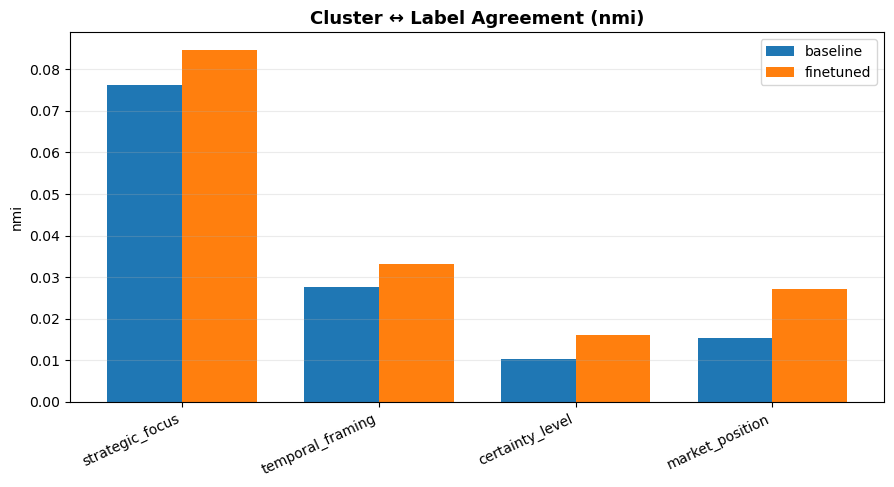

figure saved: /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_output/part3_compare_analysis__postrun__20251212_210913/figures/fig_task1_agreement_homogeneity.png


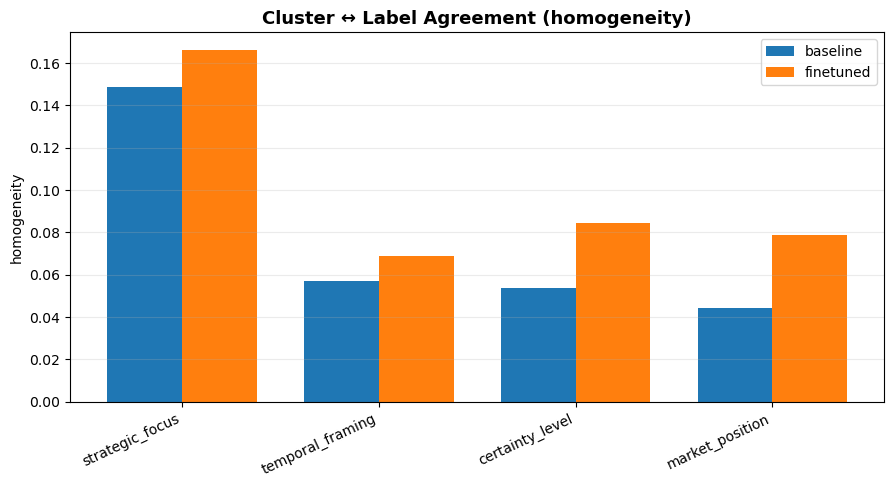

figure saved: /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_output/part3_compare_analysis__postrun__20251212_210913/figures/fig_task1_agreement_completeness.png


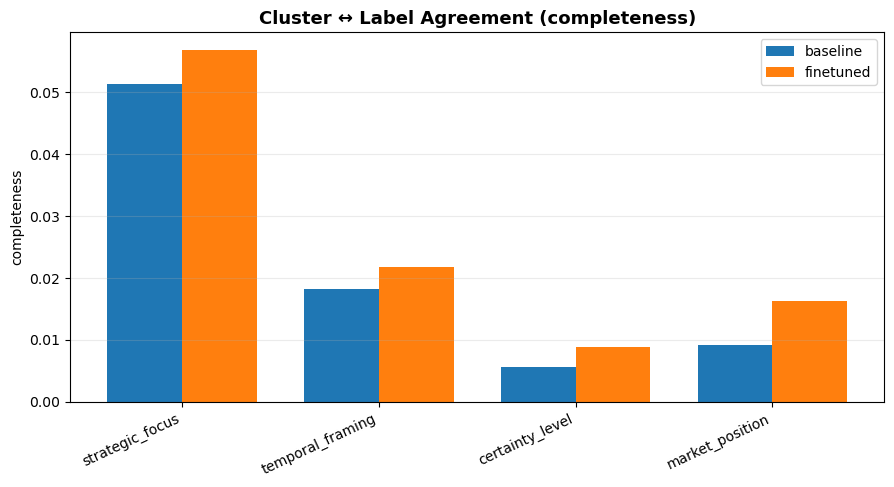


--------------------------------------------------------------------------------------------
[ TASK 2 — label consolidation (entropy + top-share) ]
--------------------------------------------------------------------------------------------

--------------------------------------------------------------------------------------------
[ TASK 2 — visuals (strategic_focus) ]
--------------------------------------------------------------------------------------------
figure saved: /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_output/part3_compare_analysis__postrun__20251212_210913/figures/fig_task2_consolidation_strategic_focus.png


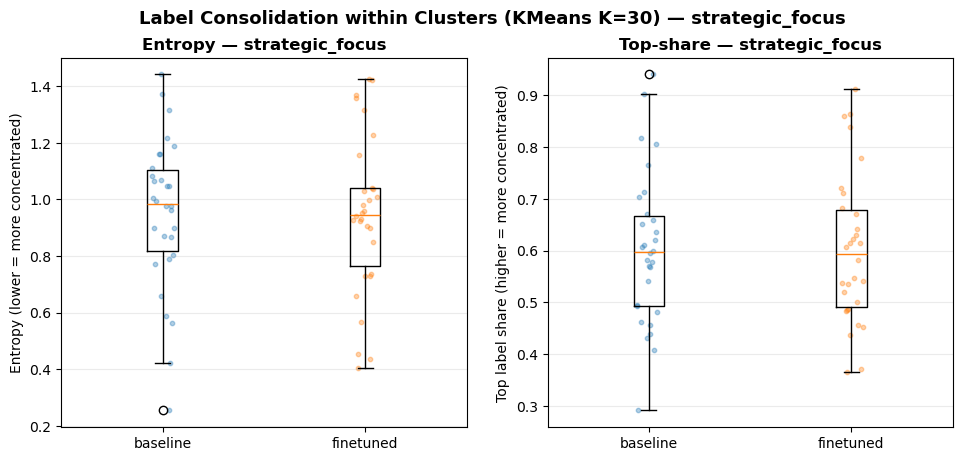


--------------------------------------------------------------------------------------------
[ TASK 2 — visuals (temporal_framing) ]
--------------------------------------------------------------------------------------------
figure saved: /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_output/part3_compare_analysis__postrun__20251212_210913/figures/fig_task2_consolidation_temporal_framing.png


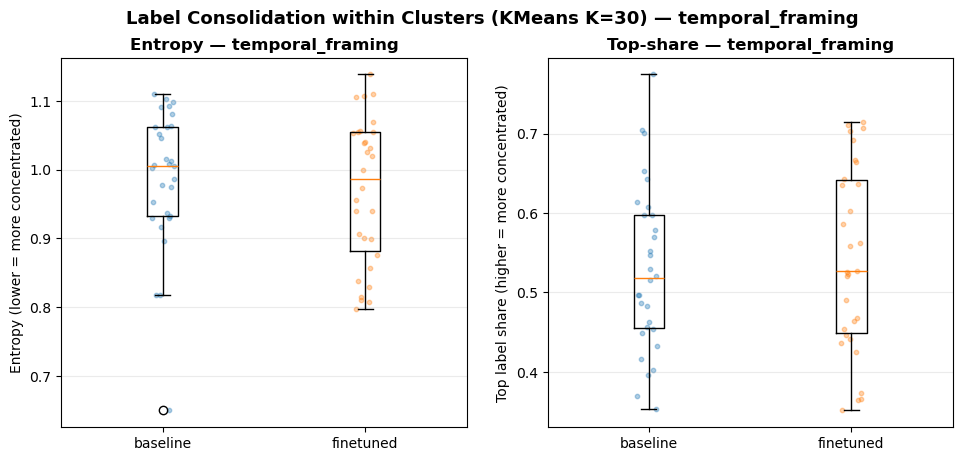

task2_label_consolidation_summary.csv saved: /Users/DJ/Dropbox/ADS_MA/IST.707/OLD_IST707-2025-SPR/Project-707/Final project delivery/IST691_phase2_output/part3_compare_analysis__postrun__20251212_210913/reports/task2_label_consolidation_summary.csv
task2_label_consolidation_summary.csv preview (top 8):
embedding_set        label_col  entropy_mean  entropy_median  top_share_mean  top_share_median
     baseline  strategic_focus      0.952722        0.984638        0.603166          0.596794
    finetuned  strategic_focus      0.945834        0.945994        0.602399          0.594319
     baseline temporal_framing      0.987616        1.005591        0.528669          0.518624
    finetuned temporal_framing      0.968354        0.986827        0.541952          0.526898
     baseline  certainty_level      0.347116        0.312833        0.880276          0.906001
    finetuned  certainty_level      0.325750        0.273590        0.889029          0.922107
     baseline  market_position 

KeyError: 'Column not found: share_within_quarter'

In [3]:
# ============================================================================================
# IST 691 — Phase 2 (Part 3)  |  Post-Run Analysis Add-on (KMeans K=30, label-aware summaries)
# Self-contained module: consumes existing Part 3 outputs + original label CSV, exports + renders.
# ============================================================================================

import os
import re
import json
import time
import math
import hashlib
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, homogeneity_score, completeness_score

# -------------------------------
# Config
# -------------------------------

CFG = {
    # project roots (assumes you run from the project root shown in your diagnostics)
    "project_root": str(Path.cwd().resolve()),
    "phase2_root": None,  # if None -> auto: <project_root>/IST691_phase2_output

    # Part 3 assignment file naming (KMeans fixed K=30)
    "baseline_assignments_name": "baseline_kmeans_k30__assignments.csv",
    "finetuned_assignments_name": "finetuned_kmeans_k30__assignments.csv",

    # Label CSV (original dataset with labels)
    "label_csv_name": "belief_extraction_results_deduped_year_quarter_flattened_repeat_deduped.csv",

    # Column names
    "id_col": "sentence_id",
    "text_col": "belief_sentence",
    "quarter_col": "year_quarter",

    # Label CSV schema (preflight shows id col is hash_id)
    "label_id_col": "hash_id",
    "label_cols": ["strategic_focus", "temporal_framing", "certainty_level", "market_position"],

    # Output: do not overwrite
    "phase2_analysis_rootname": "part3_compare_analysis__postrun",

    # Plot controls
    "seed": 42,
    "stack_top_n_clusters": 10,       # show top N clusters + Other
    "sample_sentences_per_cluster": 6,
    "sample_quarters": 4,             # number of quarters to sample for sentence tables
    "consolidation_plot_labels": ["strategic_focus", "temporal_framing"],  # reduce repeated visuals
}

# -------------------------------
# Console helpers
# -------------------------------

def _header(msg: str) -> None:
    print("\n" + "=" * 100)
    print(msg)
    print("=" * 100 + "\n")

def _section(msg: str) -> None:
    print("\n" + "-" * 92)
    print(f"[ {msg} ]")
    print("-" * 92)

def _md5(path: Path, chunk_size: int = 2**20) -> str:
    h = hashlib.md5()
    with path.open("rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def _save_csv_and_preview(df: pd.DataFrame, path: Path, label: str, n: int = 10) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"{label} saved: {path}")
    if df is None or df.empty:
        print(f"{label} preview: (empty)")
        return
    print(f"{label} preview (top {min(n, len(df))}):")
    print(df.head(n).to_string(index=False))

def _save_fig_and_show(fig: plt.Figure, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"figure saved: {path}")
    plt.show()

# -------------------------------
# Discovery helpers
# -------------------------------

def _resolve_phase2_root() -> Path:
    if CFG["phase2_root"]:
        return Path(CFG["phase2_root"]).expanduser().resolve()
    return (Path(CFG["project_root"]).expanduser().resolve() / "IST691_phase2_output").resolve()

def _find_latest_part3_dir(phase2_root: Path) -> Path:
    """
    Finds the most recent directory under phase2_root that contains both assignment files.
    """
    bname = CFG["baseline_assignments_name"]
    fname = CFG["finetuned_assignments_name"]

    candidates: List[Path] = []
    for p in phase2_root.iterdir():
        if p.is_dir() and p.name.startswith("part3_compare"):
            if (p / bname).exists() and (p / fname).exists():
                candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            f"Could not find a Part 3 directory containing both '{bname}' and '{fname}' under: {phase2_root}"
        )

    candidates.sort(key=lambda x: x.stat().st_mtime, reverse=True)
    return candidates[0].resolve()

def _resolve_label_csv(project_root: Path) -> Path:
    p = (project_root / CFG["label_csv_name"]).resolve()
    if not p.exists():
        raise FileNotFoundError(f"Label CSV not found at expected location: {p}")
    return p

# -------------------------------
# Quarter ordering
# -------------------------------

_quarter_re = re.compile(r"^\s*(\d{4})-Q([1-4])\s*$")

def _quarter_order(values: List[str]) -> List[str]:
    """
    Returns sorted unique quarters like '2015-Q1' ... in chronological order.
    """
    parsed: List[Tuple[int, int, str]] = []
    for v in values:
        if pd.isna(v):
            continue
        s = str(v)
        m = _quarter_re.match(s)
        if not m:
            continue
        y = int(m.group(1))
        q = int(m.group(2))
        parsed.append((y, q, f"{y}-Q{q}"))
    uniq = {(y, q): label for (y, q, label) in parsed}
    keys = sorted(uniq.keys())
    return [uniq[k] for k in keys]

# -------------------------------
# Data loading + integrity checks
# -------------------------------

def _read_assignments(path: Path, which: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    needed = [CFG["id_col"], CFG["quarter_col"], CFG["text_col"], "cluster_id"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"{which} assignments missing columns: {missing} | columns={list(df.columns)}")
    df[CFG["id_col"]] = df[CFG["id_col"]].astype(str)
    df[CFG["quarter_col"]] = df[CFG["quarter_col"]].astype(str)
    return df

def _read_labels(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    need = [CFG["label_id_col"]] + CFG["label_cols"]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"Label CSV missing columns: {missing} | columns={list(df.columns)}")
    df[CFG["label_id_col"]] = df[CFG["label_id_col"]].astype(str)

    # Safe merge rule: only bring label columns (avoid collisions with year_quarter/belief_sentence)
    df = df[[CFG["label_id_col"]] + CFG["label_cols"]].copy()
    return df

def _safe_merge(assign_df: pd.DataFrame, label_df: pd.DataFrame, which: str) -> pd.DataFrame:
    merged = assign_df.merge(
        label_df,
        left_on=CFG["id_col"],
        right_on=CFG["label_id_col"],
        how="left",
        validate="many_to_one",
    )
    merged.drop(columns=[CFG["label_id_col"]], inplace=True)
    # Keep year_quarter from assignments only
    return merged

# -------------------------------
# Task 1: agreement metrics (cluster ↔ label)
# -------------------------------

def _label_agreement(merged: pd.DataFrame, which: str) -> pd.DataFrame:
    rows = []
    for lc in CFG["label_cols"]:
        d = merged[[lc, "cluster_id"]].copy()
        d = d[d[lc].notna()]
        if d.empty:
            continue
        y_true = d[lc].astype(str).to_numpy()
        y_pred = d["cluster_id"].astype(int).to_numpy()

        rows.append({
            "embedding_set": which,
            "label_col": lc,
            "n_rows": int(len(d)),
            "n_labels": int(pd.Series(y_true).nunique()),
            "n_clusters": int(pd.Series(y_pred).nunique()),
            "nmi": float(normalized_mutual_info_score(y_true, y_pred)),
            "ari": float(adjusted_rand_score(y_true, y_pred)),
            "homogeneity": float(homogeneity_score(y_true, y_pred)),
            "completeness": float(completeness_score(y_true, y_pred)),
        })
    return pd.DataFrame(rows)

def _plot_agreement_bars(metrics_df: pd.DataFrame, out_dir: Path) -> None:
    if metrics_df.empty:
        return

    # long -> plot NMI + Homogeneity + Completeness as grouped bars per label_col, baseline vs finetuned
    use_cols = ["nmi", "homogeneity", "completeness"]
    label_cols = [c for c in metrics_df["label_col"].unique().tolist() if c in CFG["label_cols"]]

    for metric in use_cols:
        d = metrics_df.pivot_table(index="label_col", columns="embedding_set", values=metric, aggfunc="mean").reindex(label_cols)
        if d.isna().all().all():
            continue

        fig = plt.figure(figsize=(10.5, 4.8))
        ax = plt.gca()

        x = np.arange(len(d.index))
        width = 0.38
        ax.bar(x - width/2, d.get("baseline", pd.Series(index=d.index, dtype=float)).fillna(0).to_numpy(), width, label="baseline")
        ax.bar(x + width/2, d.get("finetuned", pd.Series(index=d.index, dtype=float)).fillna(0).to_numpy(), width, label="finetuned")

        ax.set_xticks(x)
        ax.set_xticklabels(d.index.tolist(), rotation=25, ha="right")
        ax.set_ylabel(metric)
        ax.set_title(f"Cluster ↔ Label Agreement ({metric})", fontsize=13, fontweight="bold")
        ax.grid(axis="y", alpha=0.25)
        ax.legend()

        _save_fig_and_show(fig, out_dir / f"fig_task1_agreement_{metric}.png")

# -------------------------------
# Task 2: consolidation (entropy + top-share)
# -------------------------------

def _entropy(p: np.ndarray) -> float:
    p = p[p > 0]
    if len(p) == 0:
        return 0.0
    return float(-(p * np.log(p)).sum())

def _consolidation_per_cluster(merged: pd.DataFrame, label_col: str) -> pd.DataFrame:
    d = merged[[CFG["quarter_col"], "cluster_id", label_col]].copy()
    d = d[d[label_col].notna()]
    if d.empty:
        return pd.DataFrame(columns=["cluster_id", "entropy", "top_share", "n"])

    g = d.groupby(["cluster_id", label_col]).size().reset_index(name="n")
    g["cluster_n"] = g.groupby("cluster_id")["n"].transform("sum")
    g["p"] = g["n"] / g["cluster_n"]

    # per cluster entropy + top-share
    ent = g.groupby("cluster_id")["p"].apply(lambda x: _entropy(x.to_numpy())).reset_index(name="entropy")
    top = g.groupby("cluster_id")["p"].max().reset_index(name="top_share")
    n = g.groupby("cluster_id")["cluster_n"].max().reset_index(name="n")

    out = ent.merge(top, on="cluster_id").merge(n, on="cluster_id")
    return out

def _consolidation_summary(cons: pd.DataFrame) -> Dict[str, float]:
    if cons.empty:
        return {"entropy_mean": np.nan, "entropy_median": np.nan, "top_share_mean": np.nan, "top_share_median": np.nan}
    return {
        "entropy_mean": float(cons["entropy"].mean()),
        "entropy_median": float(cons["entropy"].median()),
        "top_share_mean": float(cons["top_share"].mean()),
        "top_share_median": float(cons["top_share"].median()),
    }

def _plot_consolidation_boxplots_with_points(cons_base: pd.DataFrame, cons_fine: pd.DataFrame, label_col: str, out_dir: Path) -> None:
    rng = np.random.default_rng(int(CFG["seed"]))

    def _jitter(n: int, scale: float = 0.06) -> np.ndarray:
        return rng.uniform(-scale, scale, size=n)

    fig = plt.figure(figsize=(11.5, 4.8))

    # entropy
    ax1 = plt.subplot(1, 2, 1)
    e0 = cons_base["entropy"].to_numpy(dtype=float) if not cons_base.empty else np.array([])
    e1 = cons_fine["entropy"].to_numpy(dtype=float) if not cons_fine.empty else np.array([])
    ax1.boxplot([e0, e1], tick_labels=["baseline", "finetuned"])
    if len(e0) > 0:
        ax1.scatter(np.full(len(e0), 1.0) + _jitter(len(e0)), e0, s=10, alpha=0.35)
    if len(e1) > 0:
        ax1.scatter(np.full(len(e1), 2.0) + _jitter(len(e1)), e1, s=10, alpha=0.35)
    ax1.set_title(f"Entropy — {label_col}", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Entropy (lower = more concentrated)")
    ax1.grid(axis="y", alpha=0.25)

    # top-share
    ax2 = plt.subplot(1, 2, 2)
    t0 = cons_base["top_share"].to_numpy(dtype=float) if not cons_base.empty else np.array([])
    t1 = cons_fine["top_share"].to_numpy(dtype=float) if not cons_fine.empty else np.array([])
    ax2.boxplot([t0, t1], tick_labels=["baseline", "finetuned"])
    if len(t0) > 0:
        ax2.scatter(np.full(len(t0), 1.0) + _jitter(len(t0)), t0, s=10, alpha=0.35)
    if len(t1) > 0:
        ax2.scatter(np.full(len(t1), 2.0) + _jitter(len(t1)), t1, s=10, alpha=0.35)
    ax2.set_title(f"Top-share — {label_col}", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Top label share (higher = more concentrated)")
    ax2.grid(axis="y", alpha=0.25)

    fig.suptitle(f"Label Consolidation within Clusters (KMeans K=30) — {label_col}", fontsize=13, fontweight="bold")
    _save_fig_and_show(fig, out_dir / f"fig_task2_consolidation_{label_col}.png")

# -------------------------------
# Task 3: time-series cluster dynamics (counts + shares)
# -------------------------------

def _quarter_cluster_counts(assign_df: pd.DataFrame, which: str) -> pd.DataFrame:
    q = assign_df.groupby([CFG["quarter_col"], "cluster_id"]).size().reset_index(name="n")
    q["q_total"] = q.groupby(CFG["quarter_col"])["n"].transform("sum")
    q["share_within_quarter"] = q["n"] / q["q_total"]
    q["embedding_set"] = which
    return q

def _plot_stacked_area(d: pd.DataFrame, value_col: str, out_path: Path, title: str) -> None:
    # d: year_quarter, cluster_id, value_col (n or share), already filtered to embedding_set finetuned
    quarters = _quarter_order(d[CFG["quarter_col"]].tolist())
    if not quarters:
        return

    # choose top clusters by overall total (across time), collapse others
    totals = d.groupby("cluster_id")[value_col].sum().sort_values(ascending=False)
    top_ids = totals.head(int(CFG["stack_top_n_clusters"])).index.tolist()

    # pivot to matrix (quarters x clusters)
    m = d[d["cluster_id"].isin(top_ids)].pivot_table(
        index=CFG["quarter_col"], columns="cluster_id", values=value_col, aggfunc="sum"
    ).reindex(quarters).fillna(0.0)

    # other
    other = d[~d["cluster_id"].isin(top_ids)].groupby(CFG["quarter_col"])[value_col].sum().reindex(quarters).fillna(0.0)
    if other.sum() > 0:
        m["Other"] = other

    labels = [str(c) for c in m.columns.tolist()]

    fig = plt.figure(figsize=(12.5, 5.2))
    ax = plt.gca()
    ax.stackplot(np.arange(len(quarters)), [m[c].to_numpy(dtype=float) for c in m.columns], labels=labels, alpha=0.9)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Quarter")
    ax.set_ylabel(value_col)
    ax.set_xticks(np.arange(len(quarters)))
    ax.set_xticklabels(quarters, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.20)

    # legend outside
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), title="cluster_id", frameon=True)
    _save_fig_and_show(fig, out_path)

# -------------------------------
# Quarter-weighted purity (fixed duplicate-index bug)
# -------------------------------

def _quarter_weighted_purity(merged: pd.DataFrame, which: str, label_col: str) -> pd.DataFrame:
    """
    For each quarter: within each cluster compute purity (max label share),
    then average purity weighted by cluster size.
    """
    qc = CFG["quarter_col"]
    d = merged[[qc, "cluster_id", label_col]].copy()
    d = d[d[label_col].notna()]
    if d.empty:
        return pd.DataFrame(columns=[qc, "weighted_purity", "embedding_set", "label_col"])

    # counts per quarter+cluster+label
    g = d.groupby([qc, "cluster_id", label_col]).size().reset_index(name="n")
    g["cluster_n"] = g.groupby([qc, "cluster_id"])["n"].transform("sum")
    g["p"] = g["n"] / g["cluster_n"]

    # purity per quarter+cluster
    pur = g.groupby([qc, "cluster_id"]).agg(
        purity=("p", "max"),
        cluster_n=("cluster_n", "max"),
    ).reset_index()

    # weighted average per quarter
    out_rows = []
    for qv, sub in pur.groupby(qc, sort=False):
        w = float(np.average(sub["purity"].to_numpy(dtype=float), weights=sub["cluster_n"].to_numpy(dtype=float)))
        out_rows.append({qc: qv, "weighted_purity": w})
    out = pd.DataFrame(out_rows)

    out["embedding_set"] = which
    out["label_col"] = label_col
    return out

def _plot_weighted_purity_lines(qp_all: pd.DataFrame, label_col: str, out_dir: Path) -> None:
    """
    FIX: year_quarter duplicates exist across embedding_set; reindex safely per embedding_set.
    """
    d = qp_all[qp_all["label_col"] == label_col].copy()
    if d.empty:
        return

    quarters = _quarter_order(d["year_quarter"].tolist())
    if not quarters:
        return

    x = np.arange(len(quarters))

    fig = plt.figure(figsize=(12, 4.8))
    ax = plt.gca()

    for emb in ["baseline", "finetuned"]:
        s = d[d["embedding_set"] == emb]
        y = (
            s.set_index("year_quarter")["weighted_purity"]
             .reindex(quarters)
             .to_numpy(dtype=float)
        )
        ax.plot(x, y, marker="o", label=emb)

    ax.set_title(f"Quarter-weighted Purity — {label_col}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Weighted purity (higher = more concentrated label composition)")
    ax.set_xticks(x)
    ax.set_xticklabels(quarters, rotation=45, ha="right")
    ax.grid(alpha=0.25)
    ax.legend()

    _save_fig_and_show(fig, out_dir / f"fig_task3_weighted_purity_{label_col}.png")

# -------------------------------
# Interpretability: cluster summaries + sentence samples
# -------------------------------

def _cluster_top_labels(merged: pd.DataFrame, which: str, label_col: str, top_n: int = 5) -> pd.DataFrame:
    d = merged[["cluster_id", label_col]].copy()
    d = d[d[label_col].notna()]
    if d.empty:
        return pd.DataFrame(columns=["cluster_id", label_col, "n", "share_in_cluster", "embedding_set"])

    g = d.groupby(["cluster_id", label_col]).size().reset_index(name="n")
    g["cluster_n"] = g.groupby("cluster_id")["n"].transform("sum")
    g["share_in_cluster"] = g["n"] / g["cluster_n"]
    g["embedding_set"] = which

    g = g.sort_values(["cluster_id", "n"], ascending=[True, False])
    g["rank"] = g.groupby("cluster_id").cumcount() + 1
    out = g[g["rank"] <= top_n].drop(columns=["cluster_n", "rank"])
    return out

def _sample_sentence_tables(assign_df: pd.DataFrame, which: str, out_dir: Path) -> None:
    # sample a few quarters evenly (chronological)
    quarters_all = _quarter_order(assign_df[CFG["quarter_col"]].tolist())
    if not quarters_all:
        return

    if len(quarters_all) <= CFG["sample_quarters"]:
        quarters_pick = quarters_all
    else:
        idx = np.linspace(0, len(quarters_all) - 1, CFG["sample_quarters"]).round().astype(int)
        quarters_pick = [quarters_all[i] for i in idx]

    rows = []
    for q in quarters_pick:
        dq = assign_df[assign_df[CFG["quarter_col"]] == q].copy()
        if dq.empty:
            continue
        top_clusters = dq["cluster_id"].value_counts().head(5).index.tolist()
        for cid in top_clusters:
            dc = dq[dq["cluster_id"] == cid].head(int(CFG["sample_sentences_per_cluster"]))
            for _, r in dc.iterrows():
                rows.append({
                    "embedding_set": which,
                    "year_quarter": q,
                    "cluster_id": int(cid),
                    "belief_sentence": str(r[CFG["text_col"]]),
                })

    out = pd.DataFrame(rows)
    _save_csv_and_preview(out, out_dir / f"sample_sentences_{which}_topclusters.csv",
                          f"sample_sentences_{which}_topclusters.csv", n=25)

# -------------------------------
# Main
# -------------------------------

def main() -> None:
    t0 = time.time()
    rng = np.random.default_rng(int(CFG["seed"]))

    project_root = Path(CFG["project_root"]).expanduser().resolve()
    phase2_root = _resolve_phase2_root()

    _header("IST 691 — Phase 2 (Part 3) | Post-Run Analysis Add-on (KMeans K=30)")
    _section("startup")
    print("timestamp   :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    print("cwd         :", str(Path.cwd().resolve()))
    print("project_root:", str(project_root))
    print("phase2_root  :", str(phase2_root))

    part3_dir = _find_latest_part3_dir(phase2_root)
    _section("inputs: Part 3 assignments (auto-selected)")
    print("part3_dir:", str(part3_dir))

    base_path = (part3_dir / CFG["baseline_assignments_name"]).resolve()
    fine_path = (part3_dir / CFG["finetuned_assignments_name"]).resolve()
    print("baseline assignments :", str(base_path))
    print("finetuned assignments:", str(fine_path))
    if not base_path.exists() or not fine_path.exists():
        raise FileNotFoundError("Assignments not found in selected part3_dir.")

    label_csv = _resolve_label_csv(project_root)
    _section("inputs: label CSV")
    print("label_csv:", str(label_csv))
    print("label_md5:", _md5(label_csv))

    # output directory (no overwrite)
    run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = (phase2_root / f"{CFG['phase2_analysis_rootname']}__{run_tag}").resolve()
    reports_dir = (run_dir / "reports").resolve()
    figures_dir = (run_dir / "figures").resolve()
    run_dir.mkdir(parents=True, exist_ok=True)
    reports_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)

    _section("outputs")
    print("run_dir    :", str(run_dir))
    print("reports_dir:", str(reports_dir))
    print("figures_dir:", str(figures_dir))

    # load
    _section("load + validate")
    base_df = _read_assignments(base_path, "baseline")
    fine_df = _read_assignments(fine_path, "finetuned")
    if len(base_df) != len(fine_df):
        raise ValueError(f"Row mismatch baseline={len(base_df)} finetuned={len(fine_df)}")

    if not base_df[CFG["id_col"]].equals(fine_df[CFG["id_col"]]):
        raise ValueError("sentence_id lists do not match exactly between baseline and finetuned assignments.")

    print("baseline rows/cols :", base_df.shape)
    print("finetuned rows/cols:", fine_df.shape)
    print("baseline columns:", base_df.columns.tolist())

    print("\nassignments preview (baseline top 8):")
    print(base_df.head(8).to_string(index=False))
    print("\nassignments preview (finetuned top 8):")
    print(fine_df.head(8).to_string(index=False))

    label_df = _read_labels(label_csv)
    merged_base = _safe_merge(base_df, label_df, "baseline")
    merged_fine = _safe_merge(fine_df, label_df, "finetuned")

    # label coverage
    _section("merge coverage")
    cov_b = float(merged_base[CFG["label_cols"]].notna().all(axis=1).mean())
    cov_f = float(merged_fine[CFG["label_cols"]].notna().all(axis=1).mean())
    print("coverage baseline (all label cols non-null):", cov_b)
    print("coverage finetuned (all label cols non-null):", cov_f)
    print("\nmerged preview (baseline top 8):")
    cols_show = [CFG["id_col"], CFG["quarter_col"], "cluster_id"] + CFG["label_cols"]
    print(merged_base[cols_show].head(8).to_string(index=False))

    # -----------------------------
    # TASK 1 — cluster ↔ label agreement
    # -----------------------------
    _section("TASK 1 — cluster ↔ label agreement metrics")
    m1b = _label_agreement(merged_base, "baseline")
    m1f = _label_agreement(merged_fine, "finetuned")
    m1 = pd.concat([m1b, m1f], ignore_index=True)
    _save_csv_and_preview(m1, reports_dir / "task1_label_agreement_metrics.csv",
                          "task1_label_agreement_metrics.csv", n=20)
    _section("TASK 1 — visuals")
    _plot_agreement_bars(m1, figures_dir)

    # -----------------------------
    # TASK 2 — label consolidation within clusters
    # -----------------------------
    _section("TASK 2 — label consolidation (entropy + top-share)")
    summ_rows = []
    plot_labs = [x for x in CFG.get("consolidation_plot_labels", CFG["label_cols"]) if x in CFG["label_cols"]]

    for lc in CFG["label_cols"]:
        cb = _consolidation_per_cluster(merged_base, lc)
        cf = _consolidation_per_cluster(merged_fine, lc)

        sb = _consolidation_summary(cb)
        sf = _consolidation_summary(cf)

        summ_rows.append({"embedding_set": "baseline", "label_col": lc, **sb})
        summ_rows.append({"embedding_set": "finetuned", "label_col": lc, **sf})

        if lc in plot_labs:
            _section(f"TASK 2 — visuals ({lc})")
            _plot_consolidation_boxplots_with_points(cb, cf, lc, figures_dir)

    summ = pd.DataFrame(summ_rows)
    _save_csv_and_preview(summ, reports_dir / "task2_label_consolidation_summary.csv",
                          "task2_label_consolidation_summary.csv", n=20)

    # -----------------------------
    # TASK 3 — time-series dynamics (counts + shares; finetuned focus)
    # -----------------------------
    _section("TASK 3 — time-series cluster dynamics (counts + shares)")
    q_base = _quarter_cluster_counts(base_df, "baseline")
    q_fine = _quarter_cluster_counts(fine_df, "finetuned")
    q_all = pd.concat([q_base, q_fine], ignore_index=True)

    _save_csv_and_preview(q_all, reports_dir / "task3_quarter_cluster_distribution.csv",
                          "task3_quarter_cluster_distribution.csv", n=25)

    # finetuned application focus plots
    qf = q_fine.copy()
    _section("TASK 3 — visuals (finetuned: stacked area shares)")
    _plot_stacked_area(
        qf.rename(columns={"share_within_quarter": "share"}),  # for label
        value_col="share_within_quarter",
        out_path=figures_dir / "fig_task3_finetuned_cluster_share_stacked.png",
        title="Fine-tuned: Cluster Composition by Quarter (Share within Quarter)"
    )

    _section("TASK 3 — visuals (finetuned: stacked area counts)")
    _plot_stacked_area(
        qf,
        value_col="n",
        out_path=figures_dir / "fig_task3_finetuned_cluster_count_stacked.png",
        title="Fine-tuned: Cluster Volume by Quarter (Absolute Counts)"
    )

    # top clusters table by quarter (finetuned)
    _section("TASK 3 — top clusters per quarter (finetuned)")
    topk = (
        q_fine.sort_values(["year_quarter", "share_within_quarter"], ascending=[True, False])
              .groupby("year_quarter", as_index=False)
              .head(5)
              .copy()
    )
    _save_csv_and_preview(topk, reports_dir / "task3_finetuned_top_clusters_by_quarter.csv",
                          "task3_finetuned_top_clusters_by_quarter.csv", n=25)

    # -----------------------------
    # Quarter-weighted purity by label (fixed plotting)
    # -----------------------------
    _section("Quarter-weighted purity by label (baseline vs finetuned)")
    qp_rows = []
    for lc in plot_labs:
        qp_rows.append(_quarter_weighted_purity(merged_base, "baseline", lc))
        qp_rows.append(_quarter_weighted_purity(merged_fine, "finetuned", lc))
    qp = pd.concat(qp_rows, ignore_index=True) if qp_rows else pd.DataFrame()

    _save_csv_and_preview(qp, reports_dir / "quarter_weighted_purity_by_label.csv",
                          "quarter_weighted_purity_by_label.csv", n=25)

    if not qp.empty:
        for lc in plot_labs:
            _section(f"visual: quarter-weighted purity lines ({lc})")
            _plot_weighted_purity_lines(qp, lc, figures_dir)

    # -----------------------------
    # Interpretability: cluster → top labels (finetuned focus)
    # -----------------------------
    _section("Interpretability: cluster → top labels (strategic_focus)")
    top_labels_base = _cluster_top_labels(merged_base, "baseline", "strategic_focus", top_n=5)
    top_labels_fine = _cluster_top_labels(merged_fine, "finetuned", "strategic_focus", top_n=5)

    _save_csv_and_preview(top_labels_base, reports_dir / "cluster_top_labels_baseline__strategic_focus__top5.csv",
                          "cluster_top_labels_baseline__strategic_focus__top5.csv", n=20)
    _save_csv_and_preview(top_labels_fine, reports_dir / "cluster_top_labels_finetuned__strategic_focus__top5.csv",
                          "cluster_top_labels_finetuned__strategic_focus__top5.csv", n=20)

    # sentence samples (both; focused, limited)
    _section("Sentence samples (top clusters; selected quarters)")
    _sample_sentence_tables(base_df, "baseline", reports_dir)
    _sample_sentence_tables(fine_df, "finetuned", reports_dir)

    # -----------------------------
    # Manifest
    # -----------------------------
    _section("export manifest")
    manifest = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "project_root": str(project_root),
        "phase2_root": str(phase2_root),
        "part3_dir": str(part3_dir),
        "inputs": {
            "baseline_assignments": str(base_path),
            "finetuned_assignments": str(fine_path),
            "label_csv": str(label_csv),
            "label_csv_md5": _md5(label_csv),
        },
        "outputs": {
            "run_dir": str(run_dir),
            "reports_dir": str(reports_dir),
            "figures_dir": str(figures_dir),
        },
        "settings": {
            "seed": CFG["seed"],
            "stack_top_n_clusters": CFG["stack_top_n_clusters"],
            "consolidation_plot_labels": CFG["consolidation_plot_labels"],
        },
    }
    (run_dir / "run_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    print("manifest:", str((run_dir / "run_manifest.json").resolve()))
    print(f"elapsed_s: {time.time() - t0:.2f}")

    _header("Done.")

if __name__ == "__main__":
    main()